In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from xgboost import XGBClassifier


In [2]:
data = pd.read_csv('data/compound_5_Structural_label.csv')
data = data.loc[data.index.repeat(2)].reset_index(drop=True)


X = data.drop(columns=['label', 'compound']) 
y = data['label']

scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [3]:
import joblib

joblib.dump(scaler, 'model/feature_label_scaler.pkl')   

['model/feature_label_scaler.pkl']

In [4]:

clf = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    reg_alpha=1,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05
)
clf.fit(X_train_scale, y_train)


import numpy as np

feat_importances = clf.feature_importances_
feat_names = X.columns

num_features_to_keep = 10

top_idx = np.argsort(feat_importances)[::-1][:num_features_to_keep]

selected_features = feat_names[top_idx].tolist()
print("selected features:", selected_features)


X_train_selected = X_train_scale[:, top_idx]
X_test_selected = X_test_scale[:, top_idx]

selected features: ['feat_21', 'feat_16', 'feat_4', 'feat_6', 'feat_1', 'feat_3', 'feat_5', 'feat_13', 'feat_7', 'feat_2']


In [12]:
joblib.dump(top_idx, 'model/label_top_idx.pkl')  # 或 selected_features


['model/label_top_idx.pkl']

### XGBoost 

D:\app\miniconda\envs\p110p36\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[15:11:48] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
📊 :
              precision    recall  f1-score   support

           0      0.889     0.976     0.930        41
           1      0.944     0.773     0.850        22

    accuracy                          0.905        63
   macro avg      0.917     0.874     0.890        63
weighted avg      0.908     0.905     0.902        63



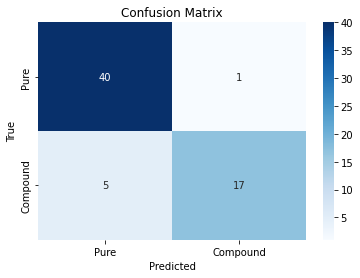

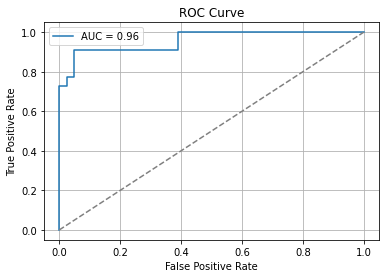

In [5]:
from sklearn.metrics import f1_score, precision_recall_curve
import numpy as np

clf = XGBClassifier(
    max_depth=3,       
    n_estimators=200,  
    learning_rate=0.05,
    reg_alpha=1,
    reg_lambda=1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42
)
clf.fit(X_train_selected, y_train)

y_pred = clf.predict(X_test_selected)
y_proba = clf.predict_proba(X_test_selected)[:, 1]

threshold = 0.7 

y_proba = clf.predict_proba(X_test_selected)[:, 1]

y_pred = (y_proba >= threshold).astype(int)


print("📊 :")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pure", "Compound"], yticklabels=["Pure", "Compound"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr,
    "Threshold": thresholds
})

print(roc_df.head())
print("AUC:", auc_score)

roc_df.to_csv("result/roc_coordinates.csv", index=False)


   FPR       TPR  Threshold
0  0.0  0.000000   1.945402
1  0.0  0.045455   0.945402
2  0.0  0.090909   0.931125
3  0.0  0.454545   0.904210
4  0.0  0.727273   0.811950
AUC: 0.9567627494456762


In [9]:
joblib.dump(clf, 'model/xgb_classifier.pkl')       


['model/xgb_classifier.pkl']